**Let's import required libraries and load & read the data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv(r"C:\Users\mahes\Desktop\python_projects\Emp_attrition_csv.csv")

In [3]:
data.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89.0,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21.0,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74.0,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50.0,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68.0,No,No,No,Fair,Medium,Stayed


**Cheeck the what are columns and how many columns are there to remove if any unwanted columns are there**

In [4]:
data.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Number of Promotions', 'Overtime',
       'Distance from Home', 'Education Level', 'Marital Status',
       'Number of Dependents', 'Job Level', 'Company Size',
       'Company Tenure (In Months)', 'Remote Work', 'Leadership Opportunities',
       'Innovation Opportunities', 'Company Reputation',
       'Employee Recognition', 'Attrition'],
      dtype='object')

In [5]:
data.drop(['Job Satisfaction','Company Tenure (In Months)',
           'Company Reputation','Employee Recognition','Number of Dependents',
           'Company Size'],axis=1,inplace=True)

**Check is there any null values or duplicated values in the data**

In [6]:
data.isna().sum()

Employee ID                    0
Age                            0
Gender                         0
Years at Company               0
Job Role                       0
Monthly Income                 0
Work-Life Balance              0
Performance Rating             0
Number of Promotions           0
Overtime                       0
Distance from Home          1912
Education Level                0
Marital Status                 0
Job Level                      0
Remote Work                    0
Leadership Opportunities       0
Innovation Opportunities       0
Attrition                      0
dtype: int64

In [7]:
data.duplicated().sum(axis=0)

np.int64(112)

**Now drop the null and duplicated values in the data**

In [8]:
data.dropna(subset=['Distance from Home'],inplace=True)

In [9]:
data.isnull().sum()

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Job Level                   0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Attrition                   0
dtype: int64

**Lets calculate average salary by Job Role**

In [10]:
data.groupby('Job Role')['Monthly Income'].mean().round()

Job Role
Education     4498.0
Finance       8591.0
Healthcare    8016.0
Media         5994.0
Technology    9224.0
Name: Monthly Income, dtype: float64

**Lets calculate attrition rate by job role**

In [11]:
# Step:1 Total employees per job role
total=data.groupby('Job Role')['Attrition'].count()
print(total)

Job Role
Education     15287
Finance       10199
Healthcare    16669
Media         11684
Technology    18859
Name: Attrition, dtype: int64


In [12]:
#Step:2 Employees who left
left=data[data['Attrition']=='Left'].groupby('Job Role')['Attrition'].count()
left

Job Role
Education     7469
Finance       4784
Healthcare    7916
Media         5492
Technology    8899
Name: Attrition, dtype: int64

In [13]:
#step 3:Attriton rate
Attriton_rate=left*100/total
Attriton_rate

Job Role
Education     48.858507
Finance       46.906559
Healthcare    47.489351
Media         47.004451
Technology    47.187019
Name: Attrition, dtype: float64

In [14]:
Employee_count=data[data['Attrition']=='Stayed'].groupby('Job Role')['Attrition'].count()
Employee_count

Job Role
Education     7818
Finance       5415
Healthcare    8753
Media         6192
Technology    9960
Name: Attrition, dtype: int64

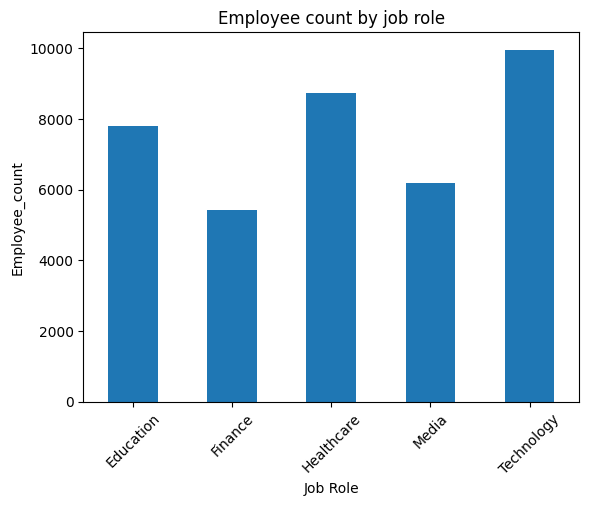

In [15]:
Employee_count.plot(kind='bar')
plt.title("Employee count by job role")
plt.xlabel("Job Role")
plt.ylabel("Employee_count")
plt.xticks(rotation=45)
plt.show()

**Visulally showing employee_count by age**

<Axes: xlabel='Age', ylabel='Count'>

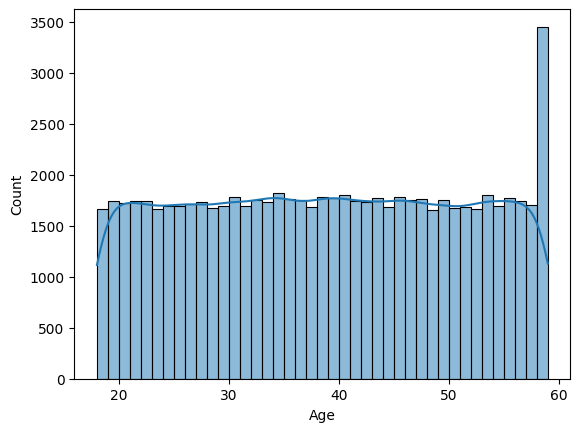

In [16]:
sns.histplot(data['Age'],kde=True)

In [17]:
data['Gender'].value_counts().sort_index(ascending=False)

Gender
Male      39811
Female    32887
Name: count, dtype: int64

In [18]:
data.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Performance Rating',
       'Number of Promotions', 'Overtime', 'Distance from Home',
       'Education Level', 'Marital Status', 'Job Level', 'Remote Work',
       'Leadership Opportunities', 'Innovation Opportunities', 'Attrition'],
      dtype='object')

**Let's Calculate attrition rate by tenure**

In [19]:
data['Attrition_flag']=data['Attrition'].map({'Stayed':0,'Left':1})

In [20]:
data.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Performance Rating',
       'Number of Promotions', 'Overtime', 'Distance from Home',
       'Education Level', 'Marital Status', 'Job Level', 'Remote Work',
       'Leadership Opportunities', 'Innovation Opportunities', 'Attrition',
       'Attrition_flag'],
      dtype='object')

In [21]:
data[['Years at Company','Attrition_flag']].corr()

,Years at Company,Attrition_flag
Years at Company,1.000000,-0.065551
Attrition_flag,-0.065551,1.000000


In [22]:
data['Tenure_Group']=pd.cut(
    data['Years at Company'],
    bins=[0,2,5,10,20,float('inf')],
    labels=['0-2','3-5','6-10','11-20','20+']
    )
attrition_rate=data.groupby('Tenure_Group')['Attrition_flag'].mean()
attrition_rate

C:\Users\mahes\AppData\Local\Temp\ipykernel_14988\1553765612.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_rate=data.groupby('Tenure_Group')['Attrition_flag'].mean()


Tenure_Group
0-2      0.528600
3-5      0.530727
6-10     0.518373
11-20    0.447499
20+      0.438001
Name: Attrition_flag, dtype: float64

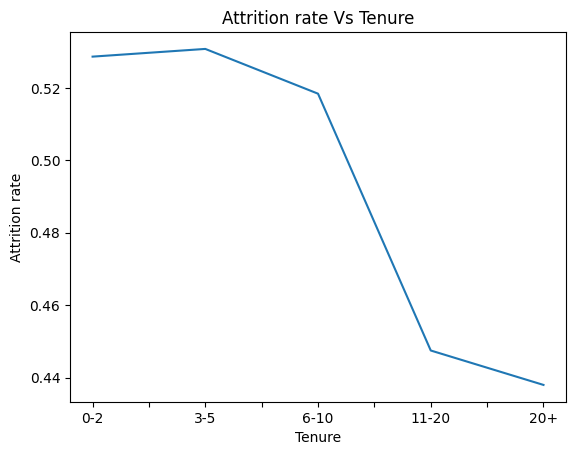

In [23]:
attrition_rate.plot(kind='line')
plt.xlabel('Tenure')
plt.ylabel('Attrition rate')
plt.title('Attrition rate Vs Tenure')
plt.show()


**Let's Calculate Attrition rate By Education level**

In [24]:
data.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Performance Rating',
       'Number of Promotions', 'Overtime', 'Distance from Home',
       'Education Level', 'Marital Status', 'Job Level', 'Remote Work',
       'Leadership Opportunities', 'Innovation Opportunities', 'Attrition',
       'Attrition_flag', 'Tenure_Group'],
      dtype='object')

In [25]:
total_by_edu=data.groupby('Education Level')['Attrition'].count()
total_by_edu

Education Level
Associate Degree       18199
Bachelorâ€™s Degree    21782
High School            14302
Masterâ€™s Degree      14691
PhD                     3724
Name: Attrition, dtype: int64

In [26]:
left_by_edu=data[data['Attrition']=='Left'].groupby('Education Level')['Attrition'].count()
left_by_edu

Education Level
Associate Degree        8859
Bachelorâ€™s Degree    10688
High School             6924
Masterâ€™s Degree       7178
PhD                      911
Name: Attrition, dtype: int64

In [27]:
Attr_per_by_edu=left_by_edu*100/total_by_edu
Attr_per_by_edu

Education Level
Associate Degree       48.678499
Bachelorâ€™s Degree    49.068038
High School            48.412809
Masterâ€™s Degree      48.859846
PhD                    24.462943
Name: Attrition, dtype: float64

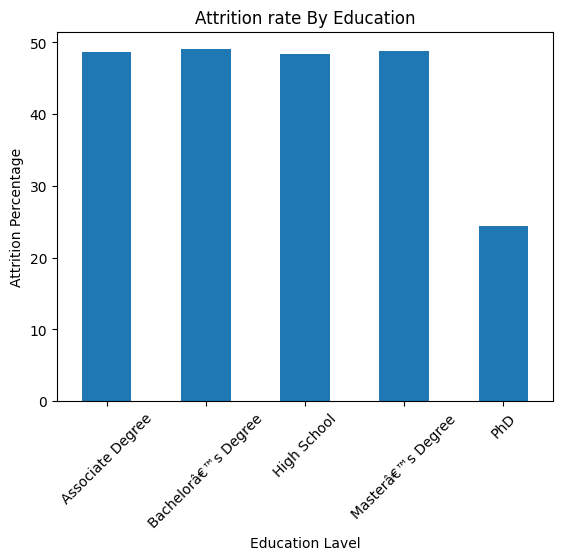

In [62]:
Attr_per_by_edu.plot(kind='bar')
plt.title('Attrition rate By Education')
plt.ylabel('Attrition Percentage')
plt.xlabel('Education Lavel')
plt.xticks(rotation=45)
plt.show()


**Checking is there any correlation between work life balance and performance of employee**

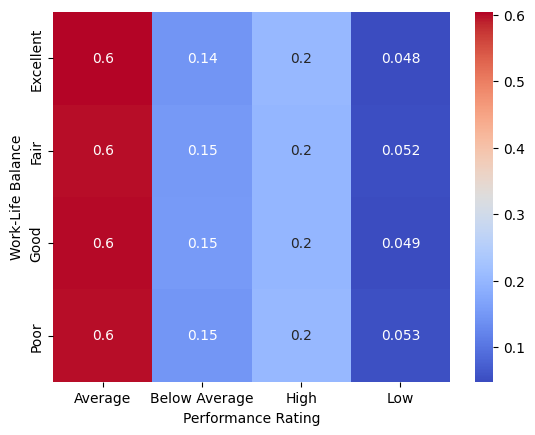

In [36]:
ct=pd.crosstab(data['Work-Life Balance'],data['Performance Rating'],normalize='index')
sns.heatmap(ct,annot=True,cmap='coolwarm')
plt.show()

*The above insights showing there no relation between worklife balance and performance of employees

 *There are mostly 60% are avg performance and 20% are high performance employees 